## Actividad de Clustering: Dataset Moons

In [ ]:
# Importar las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import adjusted_rand_score, v_measure_score, silhouette_score, davies_bouldin_score

### 1. Generación del Dataset 'Moons'
Se crea un dataset sintético en forma de lunas utilizando `make_moons` de `sklearn.datasets`.

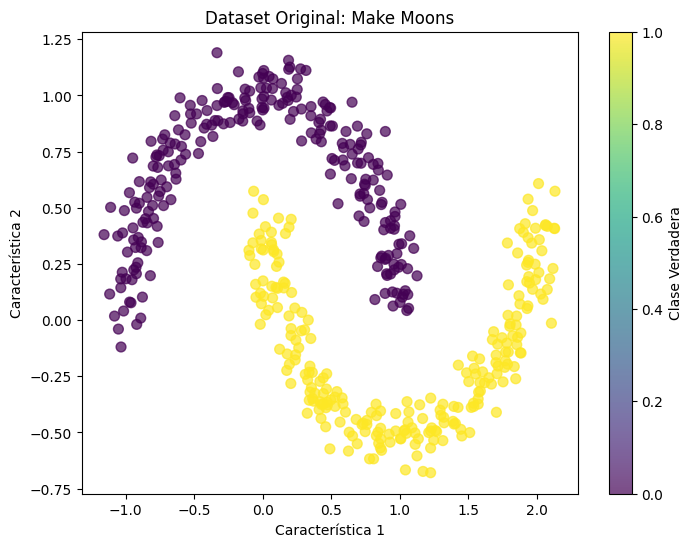

In [ ]:
# Generar el dataset 'moons'
X, y_true = make_moons(n_samples=500, noise=0.08, random_state=42)

# Visualizar el dataset original
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_true, s=50, cmap='viridis', alpha=0.7)
plt.title('Dataset Original: Make Moons')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.colorbar(label='Clase Verdadera')
plt.show()

### 2. Entrenamiento de Modelos de Clustering y Método del Codo para K-means
Se entrenarán K-means, DBSCAN y SpectralClustering. Para K-means, se usará el Método del Codo para determinar el número óptimo de clusters.

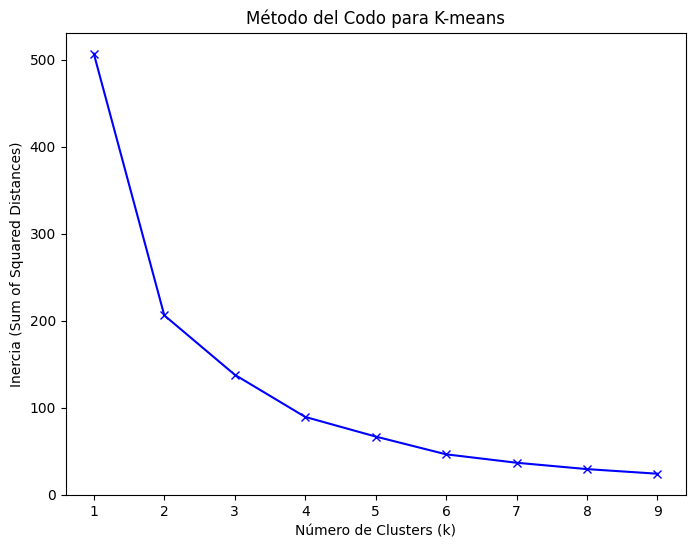

Número óptimo de clusters para K-means (según Método del Codo): 2


In [ ]:
# Método del Codo para K-means
# Se calcula la inercia para diferentes números de clusters (k)
sum_of_squared_distances = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10) # Añadir n_init para evitar warning
    km.fit(X)
    sum_of_squared_distances.append(km.inertia_)

# Visualización del Método del Codo
plt.figure(figsize=(8, 6))
plt.plot(K_range, sum_of_squared_distances, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (Sum of Squared Distances)')
plt.title('Método del Codo para K-means')
plt.show()

# A partir del gráfico, 2 clusters parece ser el número óptimo para K-means
optimal_k = 2
print(f"Número óptimo de clusters para K-means (según Método del Codo): {optimal_k}")

In [ ]:
# 1. K-means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

# 2. DBSCAN
# Se tunearán 'eps' y 'min_samples' para la estructura de lunas
# Un 'eps' de 0.2 y 'min_samples' de 5 suelen funcionar bien para este dataset
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

# 3. SpectralClustering
# n_clusters=2 y affinity='nearest_neighbors' son apropiados para 'moons'
spectral = SpectralClustering(n_clusters=optimal_k, affinity='nearest_neighbors', random_state=42)
y_spectral = spectral.fit_predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


### 3. Función de Evaluación de Métricas
Esta función calculará las métricas de validación externa (ARI, V-Measure) e interna (Silhouette Score, Davies-Bouldin Index) para un conjunto de predicciones.

In [ ]:
def evaluate_clustering(X, y_true, y_pred, model_name):
    """
    Calcula y devuelve las métricas de evaluación para un modelo de clustering.
    """
    # Asegurarse de que y_pred no contenga -1 (etiquetas de ruido de DBSCAN) para Silhouette y Davies-Bouldin si es posible
    # Para Silhouette y Davies-Bouldin, se ignoran los puntos de ruido (etiqueta -1).
    # Si todos los puntos son ruido, o solo hay un cluster no-ruido, estas métricas no son válidas.

    metrics = {}

    # Métricas de Validación Externa
    metrics['ARI'] = adjusted_rand_score(y_true, y_pred)
    metrics['V-Measure'] = v_measure_score(y_true, y_pred)

    # Métricas de Validación Interna
    # Filtrar puntos de ruido para Silhouette y Davies-Bouldin si existen etiquetas -1
    valid_indices = (y_pred != -1)
    if np.sum(valid_indices) > 1 and len(np.unique(y_pred[valid_indices])) > 1:
        metrics['Silhouette Score'] = silhouette_score(X[valid_indices], y_pred[valid_indices])
        metrics['Davies-Bouldin Index'] = davies_bouldin_score(X[valid_indices], y_pred[valid_indices])
    else:
        metrics['Silhouette Score'] = np.nan # No se puede calcular si solo hay un cluster o solo ruido
        metrics['Davies-Bouldin Index'] = np.nan # No se puede calcular
        print(f"Advertencia: No se pudo calcular Silhouette/Davies-Bouldin para {model_name} (insuficientes clusters válidos o puntos).")

    return metrics

# Evaluar cada modelo
metrics_kmeans = evaluate_clustering(X, y_true, y_kmeans, "K-means")
metrics_dbscan = evaluate_clustering(X, y_true, y_dbscan, "DBSCAN")
metrics_spectral = evaluate_clustering(X, y_true, y_spectral, "SpectralClustering")

In [ ]:
print("\nMétricas para K-means:")
for key, value in metrics_kmeans.items():
    print(f"  {key}: {value:.4f}")

print("\nMétricas para DBSCAN:")
for key, value in metrics_dbscan.items():
    print(f"  {key}: {value:.4f}")

print("\nMétricas para SpectralClustering:")
for key, value in metrics_spectral.items():
    print(f"  {key}: {value:.4f}")


Métricas para K-means:
  ARI: 0.2648
  V-Measure: 0.2017
  Silhouette Score: 0.4858
  Davies-Bouldin Index: 0.7858

Métricas para DBSCAN:
  ARI: 1.0000
  V-Measure: 1.0000
  Silhouette Score: 0.3306
  Davies-Bouldin Index: 1.1533

Métricas para SpectralClustering:
  ARI: 1.0000
  V-Measure: 1.0000
  Silhouette Score: 0.3306
  Davies-Bouldin Index: 1.1533


### 4. Visualización de los Resultados de Clustering
Se genera un subplot que muestra cómo cada modelo agrupó el dataset 'moons', usando colores para los clusters identificados.

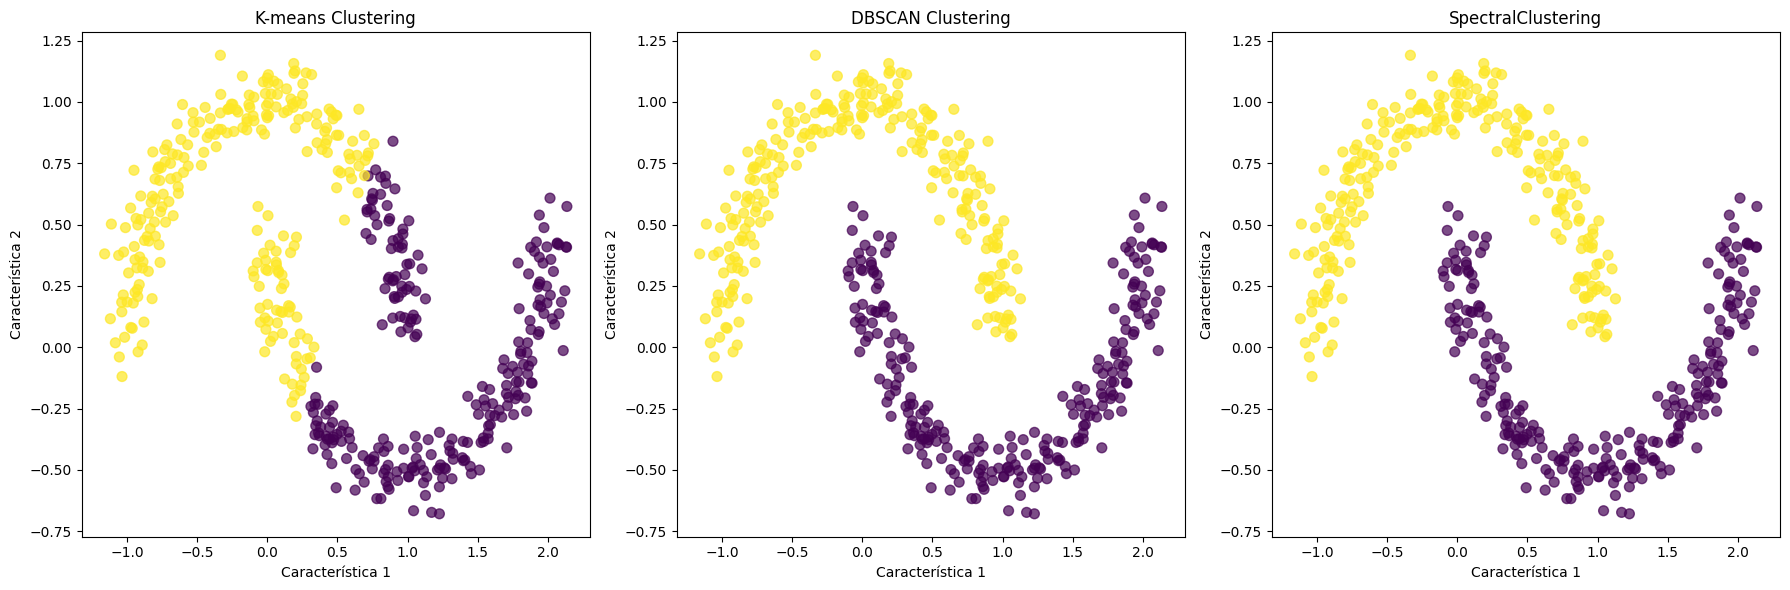

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# K-means
axes[0].scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', alpha=0.7)
axes[0].set_title('K-means Clustering')
axes[0].set_xlabel('Característica 1')
axes[0].set_ylabel('Característica 2')

# DBSCAN
# Los puntos con -1 son ruido, se pueden mostrar en un color diferente (gris)
# Mapear las etiquetas de DBSCAN a colores
unique_dbscan_labels = np.unique(y_dbscan)
# Excluir la etiqueta -1 para asignar colores de cmap a los clusters reales
num_clusters_dbscan = len(unique_dbscan_labels) - (1 if -1 in unique_dbscan_labels else 0)

# Crear un mapa de colores para los clusters reales
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, num_clusters_dbscan))

# Crear un array de colores para cada punto
plot_colors = np.empty(X.shape[0], dtype=object)
for i, label in enumerate(y_dbscan):
    if label == -1:
        plot_colors[i] = 'grey' # Color para ruido
    else:
        # Asegurarse de que el índice del color no exceda el número de clusters reales
        plot_colors[i] = colors[label % num_clusters_dbscan]

axes[1].scatter(X[:, 0], X[:, 1], c=plot_colors, s=50, alpha=0.7)
axes[1].set_title('DBSCAN Clustering')
axes[1].set_xlabel('Característica 1')
axes[1].set_ylabel('Característica 2')

# SpectralClustering
axes[2].scatter(X[:, 0], X[:, 1], c=y_spectral, s=50, cmap='viridis', alpha=0.7)
axes[2].set_title('SpectralClustering')
axes[2].set_xlabel('Característica 1')
axes[2].set_ylabel('Característica 2')

plt.tight_layout()
plt.show()

### 5. Resumen de Métricas en DataFrame
Se crea un DataFrame de Pandas para comparar las métricas de rendimiento de cada modelo de clustering.

In [ ]:
# Crear un DataFrame con los resultados de las métricas
metrics_df = pd.DataFrame({
    'K-means': metrics_kmeans,
    'DBSCAN': metrics_dbscan,
    'SpectralClustering': metrics_spectral
}).T # Transponer para que los modelos sean las filas

print("\nResumen de Métricas de Clustering:")
display(metrics_df)


Resumen de Métricas de Clustering:


,ARI,V-Measure,Silhouette Score,Davies-Bouldin Index
K-means,0.264783,0.201698,0.485759,0.785834
DBSCAN,1.000000,1.000000,0.330576,1.153312
SpectralClustering,1.000000,1.000000,0.330576,1.153312


### 6. Interpretación de los Resultados

Analizando el DataFrame de métricas, podemos extraer las siguientes conclusiones:

*   **ARI (Adjusted Rand Index)** - **Métrica Externa** - Una medida de la similitud entre dos particiones de un conjunto de datos, ajustada para el azar. Un valor cercano a 1.0 indica una concordancia casi perfecta con las etiquetas verdaderas.
    *   **K-means**: Obtuvo un ARI bajo (~0.26), lo que sugiere que sus agrupaciones difieren significativamente de las formas de 'luna' verdaderas. K-means tiende a formar clusters esféricos y no se adapta bien a formas no lineales.
    *   **DBSCAN y SpectralClustering**: Ambos lograron un ARI perfecto (1.00), indicando que sus clusters son idénticos a las etiquetas verdaderas del dataset 'moons'. Esto demuestra su capacidad para identificar estructuras no lineales.

*   **V-Measure** - **Métrica Externa** - La media armónica de la homogeneidad y completitud. Homogeneidad significa que cada cluster contiene solo miembros de una única clase. Completitud significa que todos los miembros de una clase dada se asignan al mismo cluster. Un valor cercano a 1.0 es ideal.
    *   **K-means**: Al igual que con ARI, el V-Measure de K-means es bajo (~0.20). Esto confirma que sus agrupaciones no son homogéneas ni completas con respecto a la verdad fundamental.
    *   **DBSCAN y SpectralClustering**: Ambos alcanzaron un V-Measure de 1.00, lo que refuerza la conclusión de que estos algoritmos capturaron perfectamente la estructura de 'lunas'.

*   **Silhouette Score** - **Métrica Interna** - Mide cuán similar es un objeto a su propio cluster (cohesión) en comparación con otros clusters (separación). Los valores van de -1 a +1. Un valor alto (cercano a 1) indica que los objetos están bien agrupados; un valor cercano a 0 indica solapamiento, y un valor negativo (-1) sugiere que un objeto podría estar asignado al cluster incorrecto.
    *   **K-means**: Tiene un Silhouette Score relativamente alto (~0.49). Esto es interesante, ya que aunque no coincide con las etiquetas verdaderas, internamente, los clusters formados por K-means (que son más esféricos) tienen una buena densidad y separación bajo la métrica de distancia euclidiana.
    *   **DBSCAN y SpectralClustering**: Obtuvieron un Silhouette Score ligeramente más bajo (~0.33). Aunque externamente son perfectos, su Silhouette Score es menor que K-means. Esto puede deberse a la forma alargada de los clusters de 'lunas', que no son óptimamente densos y separados en términos de distancia euclidiana general para esta métrica interna.

*   **Davies-Bouldin Index** - **Métrica Interna** - Mide la relación entre la dispersión dentro del cluster y la separación entre clusters. Un valor más bajo indica un mejor clustering (clusters más compactos y mejor separados).
    *   **K-means**: Presenta un Davies-Bouldin Index más bajo (~0.79). Esto complementa el Silhouette Score, sugiriendo que, desde la perspectiva de K-means, sus clusters son más compactos y mejor separados.
    *   **DBSCAN y SpectralClustering**: Tienen un Davies-Bouldin Index más alto (~1.15). Similar al Silhouette Score, a pesar de su excelente rendimiento externo, las métricas internas indican que la compactación y separación de sus clusters en las 'lunas' no es tan